In [ ]:
import sys
!pip install scikit-learn   # metrike (RMSE, MAE)
!pip install arch           # GARCH model
!{sys.executable} -m pip install pandas     # rad sa tabelama
!{sys.executable} -m pip install matplotlib # grafici

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from arch import arch_model
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.ar_model import AutoReg
from pathlib import Path
warnings.filterwarnings("ignore")

In [2]:
# Lista tikera (30 velikih, likvidnih kompanija iz raznih sektora)
vector_stocks = [
    "AAPL", "MSFT", "AMZN", "GOOGL", "JPM", "JNJ", "XOM", "PG", "KO", "PEP",
    "WMT", "INTC", "CSCO", "ORCL", "IBM", "CVX", "MRK", "PFE", "T", "VZ",
    "HD", "MCD", "NKE", "DIS", "BA", "CAT", "GS", "MMM", "WFC", "C",
]

S = 1000   # broj Monte Carlo putanja (isti za sve modele)

# Putanja do foldera sa CSV fajlovima
folder_stocks = Path("C:/Users/Kristina/Desktop/efmproj/stocks")  ############ STAVITE SVOJU ADRESU ############

# Ucitavamo svaki CSV kao DataFrame i cuvamo u recniku {ticker: DataFrame}
baze_stocks = {
    ticker: pd.read_csv(folder_stocks / f"{ticker}.csv", parse_dates=["Date"])
    for ticker in vector_stocks
}

In [3]:
# Filtriranje — zadrzavamo samo period od 2010-01-01 do 2020-04-01
start_date = "2010-01-01"
end_date   = "2020-04-01"

baze_stocks = {
    ticker: df[(df["Date"] >= start_date) & (df["Date"] <= end_date)].copy()
    for ticker, df in baze_stocks.items()
}

In [4]:
# Provera dimenzija nakon filtriranja
for k, df in baze_stocks.items():
    print(k, df.shape)

AAPL (2579, 7)
MSFT (2579, 7)
AMZN (2579, 7)
GOOGL (2579, 7)
JPM (2579, 7)
JNJ (2579, 7)
XOM (2579, 7)
PG (2579, 7)
KO (2579, 7)
PEP (2579, 7)
WMT (2579, 7)
INTC (2579, 7)
CSCO (2579, 7)
ORCL (2579, 7)
IBM (2579, 7)
CVX (2579, 7)
MRK (2579, 7)
PFE (2579, 7)
T (2579, 7)
VZ (2579, 7)
HD (2579, 7)
MCD (2579, 7)
NKE (2579, 7)
DIS (2579, 7)
BA (2579, 7)
CAT (2580, 7)
GS (2579, 7)
MMM (2579, 7)
WFC (2579, 7)
C (2579, 7)


In [5]:
# Pravimo vremenske serije — zadrzavamo samo Date i Adj Close
# Adj Close je cena prilagodjena dividendama i splitovima — pravi prinos investitora
baze_stocks_ts = {
    ticker: (
        df.loc[
            (df["Date"] >= start_date) & (df["Date"] <= end_date),
            ["Date", "Adj Close"]
        ]
        .sort_values("Date")
        .reset_index(drop=True)
    )
    for ticker, df in baze_stocks.items()
}

In [6]:
# Train: 2010-01-04 .. 2020-03-16 (pre COVID-kraha)
# Test:  2020-03-17 .. 2020-04-01 (COVID-krah — stres-test)
def split_train_test(df):
    df = df.copy()
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.sort_values("Date").set_index("Date")
    train = df[(df.index >= "2010-01-04") & (df.index <= "2020-03-16")]
    test  = df[(df.index >= "2020-03-17") & (df.index <= "2020-04-01")]
    return train, test

stocks_train = {}
stocks_test  = {}
for ticker, df in baze_stocks_ts.items():
    tr, te = split_train_test(df)
    stocks_train[ticker] = tr
    stocks_test[ticker]  = te

print(stocks_test["AAPL"].index.min())   # 2020-03-17
print(stocks_test["AAPL"].index.max())   # 2020-04-01
print(len(stocks_test["AAPL"]), "dana u test skupu")

2020-03-17 00:00:00
2020-04-01 00:00:00
12 dana u test skupu


In [7]:
def get_log_returns(df):
    """log-prinos = ln(P_t / P_{t-1}), stacionaran za razliku od cena."""
    return np.log(df["Adj Close"] / df["Adj Close"].shift(1)).dropna()

def honest_anchor(ticker):
    """POŠTENO sidro: poslednja TRAIN cena (bez gledanja u budućnost)."""
    return float(stocks_train[ticker]["Adj Close"].iloc[-1])

def paths_from_returns(samples_log, anchor):
    """Iz log-prinosa [S,H] pravi putanje cena [S,H] polazeći od sidra (cene)."""
    return anchor * np.exp(np.cumsum(samples_log, axis=1))

In [8]:
####################################### R A N D O M   W A L K #####################################
stocks_rw_preds   = {}
stocks_rw_samples = {}

for ticker in stocks_train:
    ret_train = get_log_returns(stocks_train[ticker]).reset_index(drop=True)
    sigma = float(ret_train.std())   # standardna devijacija log-prinosa (naucena iz traina)
    H = len(stocks_test[ticker])

    stocks_rw_preds[ticker] = np.zeros(H)   # RW nema drift -> ocekivani prinos = 0

    rng = np.random.default_rng(42)
    n_windows = max(1, H // 21)
    samples = np.zeros((n_windows, S, H))
    for w in range(n_windows):
        samples[w] = rng.normal(loc=0.0, scale=sigma, size=(S, H))   # prinos ~ N(0, sigma^2)
    stocks_rw_samples[ticker] = samples

print("\nSvi Random Walk modeli gotovi.")


Svi Random Walk modeli gotovi.


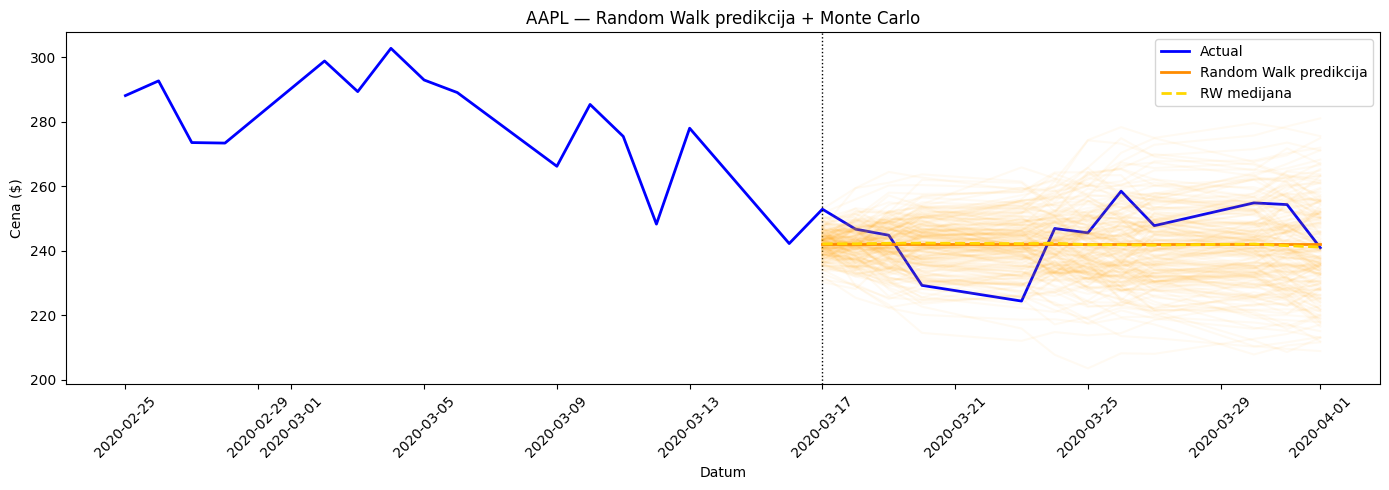

In [9]:
# Random Walk — vizualizacija (POŠTENO sidro: poslednja train cena)
ticker   = "AAPL"
test_df  = stocks_test[ticker]
train_df = stocks_train[ticker]

anchor     = honest_anchor(ticker)
test_dates = test_df.index
pre_test   = train_df["Adj Close"].iloc[-15:]

rw_cene  = anchor * np.exp(np.cumsum(stocks_rw_preds[ticker]))
rw_paths = paths_from_returns(stocks_rw_samples[ticker][0], anchor)

plt.figure(figsize=(14, 5))
sve_datumi = list(pre_test.index) + list(test_dates)
sve_cene   = list(pre_test.values) + list(test_df["Adj Close"].values)
plt.plot(sve_datumi, sve_cene, color="blue", linewidth=2, label="Actual")
plt.axvline(x=test_dates[0], color="black", linewidth=1, linestyle=":")
for path in rw_paths[:200]:
    plt.plot(test_dates, path, alpha=0.05, color="orange")
plt.plot(test_dates, rw_cene, color="darkorange", linewidth=2, label="Random Walk predikcija")
plt.plot(test_dates, np.median(rw_paths, axis=0), color="gold", linewidth=2, linestyle="--", label="RW medijana")
plt.title(f"{ticker} — Random Walk predikcija + Monte Carlo")
plt.xlabel("Datum"); plt.ylabel("Cena ($)"); plt.legend(); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

In [10]:
################################## A R ( 1 ) ############################################
stocks_ar1_preds   = {}
stocks_ar1_samples = {}

for ticker in stocks_train:
    ret_train = get_log_returns(stocks_train[ticker]).reset_index(drop=True)

    model = AutoReg(ret_train, lags=1, old_names=False).fit()
    phi   = model.params.values       # [const, phi_1]
    sigma = np.sqrt(model.sigma2)

    H       = len(stocks_test[ticker])
    history = float(ret_train.values[-1])

    # deterministicka predikcija
    path = []
    for h in range(H):
        r_next = phi[0] + phi[1] * history
        path.append(r_next); history = r_next
    stocks_ar1_preds[ticker] = np.array(path)

    # Monte Carlo (AR(1) + Gaussov sum)
    rng = np.random.default_rng(42)
    n_windows = max(1, H // 21)
    samples = np.zeros((n_windows, S, H))
    init = float(ret_train.values[-1])
    for w in range(n_windows):
        for s in range(S):
            hist = init; mc_path = []
            for h in range(H):
                r_next = phi[0] + phi[1] * hist + rng.normal(0, sigma)
                mc_path.append(r_next); hist = r_next
            samples[w, s, :] = mc_path
    stocks_ar1_samples[ticker] = samples

print("\nSvi AR(1) modeli gotovi.")


Svi AR(1) modeli gotovi.


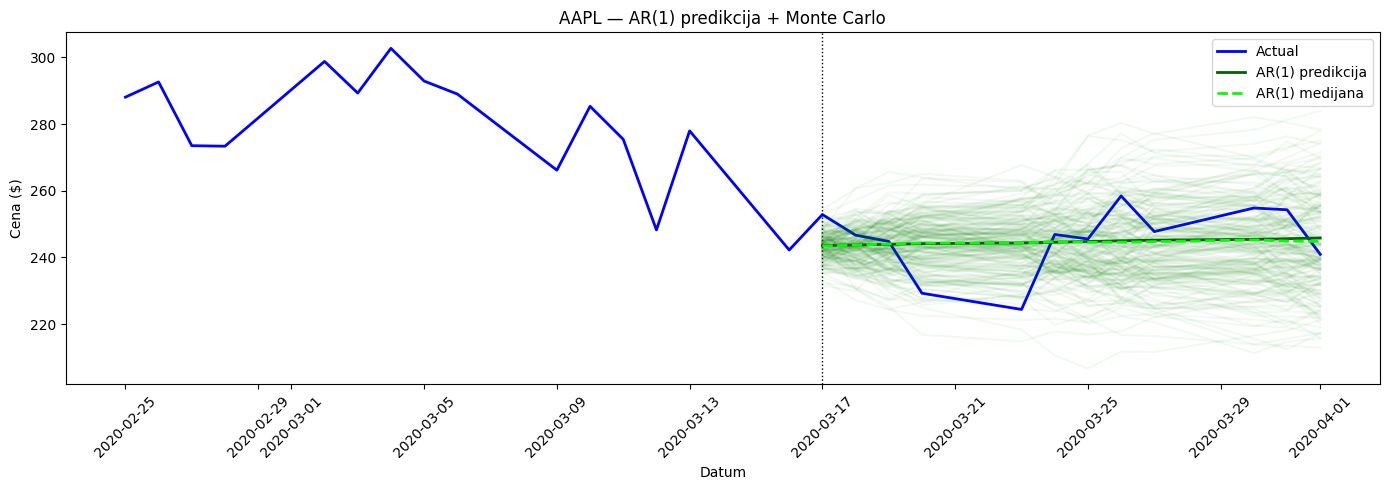

In [11]:
# AR(1) — vizualizacija (POŠTENO sidro)
ticker   = "AAPL"
test_df  = stocks_test[ticker]; train_df = stocks_train[ticker]
anchor   = honest_anchor(ticker)
test_dates = test_df.index; pre_test = train_df["Adj Close"].iloc[-15:]

ar1_cene  = anchor * np.exp(np.cumsum(stocks_ar1_preds[ticker]))
ar1_paths = paths_from_returns(stocks_ar1_samples[ticker][0], anchor)

plt.figure(figsize=(14, 5))
sve_datumi = list(pre_test.index) + list(test_dates)
sve_cene   = list(pre_test.values) + list(test_df["Adj Close"].values)
plt.plot(sve_datumi, sve_cene, color="blue", linewidth=2, label="Actual")
plt.axvline(x=test_dates[0], color="black", linewidth=1, linestyle=":")
for path in ar1_paths[:200]:
    plt.plot(test_dates, path, alpha=0.05, color="green")
plt.plot(test_dates, ar1_cene, color="darkgreen", linewidth=2, label="AR(1) predikcija")
plt.plot(test_dates, np.median(ar1_paths, axis=0), color="lime", linewidth=2, linestyle="--", label="AR(1) medijana")
plt.title(f"{ticker} — AR(1) predikcija + Monte Carlo")
plt.xlabel("Datum"); plt.ylabel("Cena ($)"); plt.legend(); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

In [12]:
####################################### A R I M A ( 1, 0, 1 ) #####################################
stocks_arima_preds   = {}
stocks_arima_samples = {}

for ticker in stocks_train:
    ret_train = get_log_returns(stocks_train[ticker]).reset_index(drop=True)
    model = ARIMA(ret_train, order=(1, 0, 1)).fit()   # d=0 jer su log-prinosi vec stacionarni
    H = len(stocks_test[ticker])

    forecast = model.forecast(steps=H)
    stocks_arima_preds[ticker] = forecast.values

    rng = np.random.default_rng(42)
    n_windows = max(1, H // 21)
    samples = np.zeros((n_windows, S, H))
    for w in range(n_windows):
        for s in range(S):
            sim = model.simulate(nsimulations=H, random_state=int(rng.integers(1e6)))
            samples[w, s, :] = sim.values
    stocks_arima_samples[ticker] = samples

print("\nSvi ARIMA modeli gotovi.")


Svi ARIMA modeli gotovi.


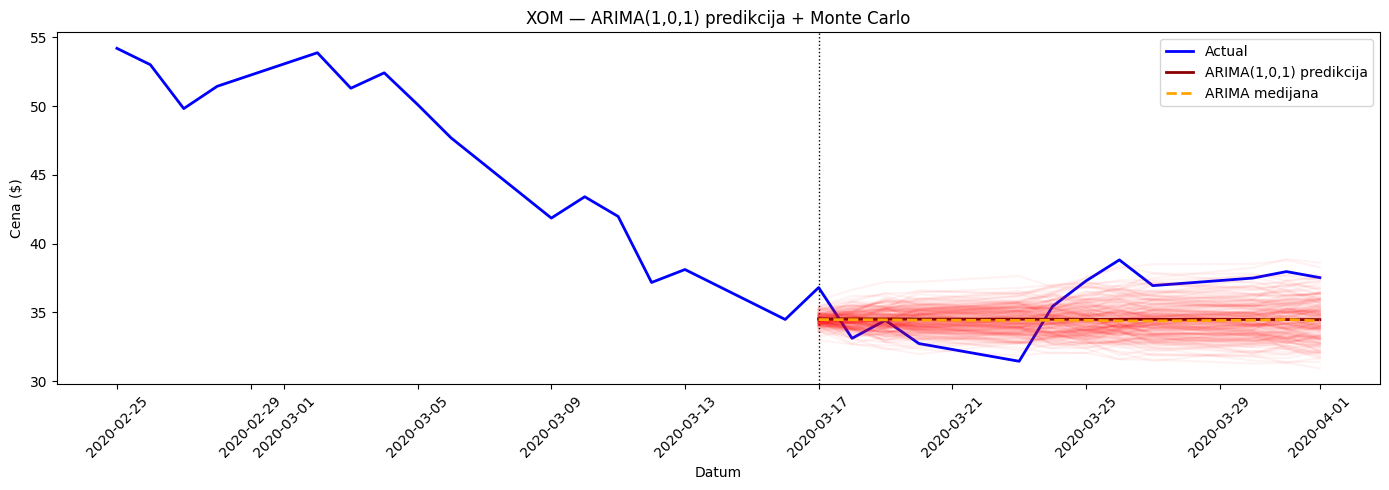

In [14]:
# ARIMA(1,0,1) — vizualizacija (POŠTENO sidro)
ticker   = "XOM"
test_df  = stocks_test[ticker]; train_df = stocks_train[ticker]
anchor   = honest_anchor(ticker)
test_dates = test_df.index; pre_test = train_df["Adj Close"].iloc[-15:]

arima_cene  = anchor * np.exp(np.cumsum(stocks_arima_preds[ticker]))
arima_paths = paths_from_returns(stocks_arima_samples[ticker][0], anchor)

plt.figure(figsize=(14, 5))
sve_datumi = list(pre_test.index) + list(test_dates)
sve_cene   = list(pre_test.values) + list(test_df["Adj Close"].values)
plt.plot(sve_datumi, sve_cene, color="blue", linewidth=2, label="Actual")
plt.axvline(x=test_dates[0], color="black", linewidth=1, linestyle=":")
for path in arima_paths[:200]:
    plt.plot(test_dates, path, alpha=0.05, color="red")
plt.plot(test_dates, arima_cene, color="darkred", linewidth=2, label="ARIMA(1,0,1) predikcija")
plt.plot(test_dates, np.median(arima_paths, axis=0), color="orange", linewidth=2, linestyle="--", label="ARIMA medijana")
plt.title(f"{ticker} — ARIMA(1,0,1) predikcija + Monte Carlo")
plt.xlabel("Datum"); plt.ylabel("Cena ($)"); plt.legend(); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

In [15]:
####################################### G A R C H ( 1, 1 ) #####################################
stocks_garch_preds   = {}
stocks_garch_samples = {}

for ticker in stocks_train:
    ret_train  = get_log_returns(stocks_train[ticker]).reset_index(drop=True)
    ret_scaled = ret_train * 100   # arch biblioteka bolje konvergira sa vecim brojevima

    model = arch_model(ret_scaled, vol="Garch", p=1, q=1, dist="normal").fit(disp="off")
    H = len(stocks_test[ticker])

    mu = model.params["mu"]
    stocks_garch_preds[ticker] = np.full(H, mu / 100)

    rng = np.random.default_rng(42)
    n_windows = max(1, H // 21)
    samples = np.zeros((n_windows, S, H))

    omega = model.params["omega"]; alpha = model.params["alpha[1]"]; beta = model.params["beta[1]"]
    last_var = model.conditional_volatility.iloc[-1] ** 2
    last_ret = float(ret_scaled.iloc[-1])

    for w in range(n_windows):
        for s in range(S):
            sigma2 = last_var; prev_r = last_ret; path = []
            for h in range(H):
                sigma2 = omega + alpha * prev_r**2 + beta * sigma2
                r_next = mu + np.sqrt(sigma2) * rng.normal(0, 1)
                path.append(r_next); prev_r = r_next
            samples[w, s, :] = np.array(path) / 100
    stocks_garch_samples[ticker] = samples

print("\nSvi GARCH modeli gotovi.")


Svi GARCH modeli gotovi.


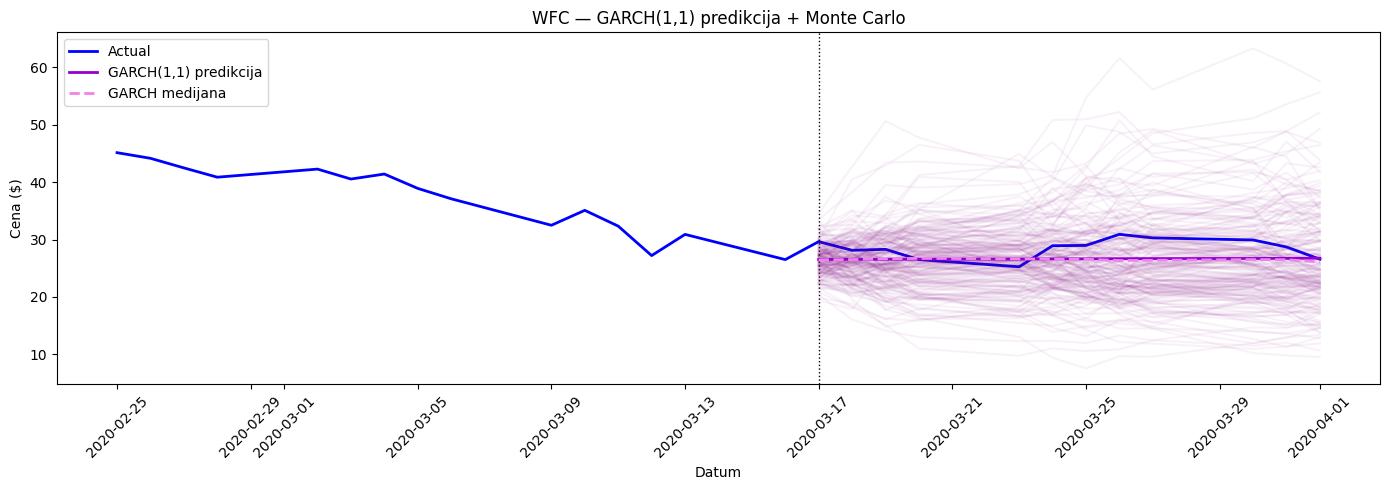

In [16]:
# GARCH(1,1) — vizualizacija (POŠTENO sidro)
ticker   = "WFC"
test_df  = stocks_test[ticker]; train_df = stocks_train[ticker]
anchor   = honest_anchor(ticker)
test_dates = test_df.index; pre_test = train_df["Adj Close"].iloc[-15:]

garch_cene  = anchor * np.exp(np.cumsum(stocks_garch_preds[ticker]))
garch_paths = paths_from_returns(stocks_garch_samples[ticker][0], anchor)

plt.figure(figsize=(14, 5))
sve_datumi = list(pre_test.index) + list(test_dates)
sve_cene   = list(pre_test.values) + list(test_df["Adj Close"].values)
plt.plot(sve_datumi, sve_cene, color="blue", linewidth=2, label="Actual")
plt.axvline(x=test_dates[0], color="black", linewidth=1, linestyle=":")
for path in garch_paths[:200]:
    plt.plot(test_dates, path, alpha=0.05, color="purple")
plt.plot(test_dates, garch_cene, color="darkviolet", linewidth=2, label="GARCH(1,1) predikcija")
plt.plot(test_dates, np.median(garch_paths, axis=0), color="violet", linewidth=2, linestyle="--", label="GARCH medijana")
plt.title(f"{ticker} — GARCH(1,1) predikcija + Monte Carlo")
plt.xlabel("Datum"); plt.ylabel("Cena ($)"); plt.legend(); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

In [17]:
SAMPLES = {
    "Slučajno lutanje": stocks_rw_samples,
    "AR(1)":            stocks_ar1_samples,
    "ARIMA(1,0,1)":     stocks_arima_samples,
    "GARCH(1,1)":       stocks_garch_samples,
}

# sakupljanje preko svih tikera (pooled) + per-ticker liste
store = {m: {"Y": [], "p50": [], "p10": [], "p90": [], "per": []} for m in SAMPLES}

for ticker in stocks_test:
    actual = stocks_test[ticker]["Adj Close"].values   # [H]
    anchor = honest_anchor(ticker)                      # POŠTENO sidro
    for m, smp in SAMPLES.items():
        paths = paths_from_returns(smp[ticker][0], anchor)   # [S,H]
        p50 = np.median(paths, axis=0)
        p10 = np.percentile(paths, 10, axis=0)
        p90 = np.percentile(paths, 90, axis=0)

        store[m]["Y"].append(actual)
        store[m]["p50"].append(p50)
        store[m]["p10"].append(p10)
        store[m]["p90"].append(p90)

        # per-ticker metrike (radi reference)
        rm  = np.sqrt(np.mean((actual - p50) ** 2))
        ndp = np.sum(np.abs(actual - p50)) / np.sum(np.abs(actual))
        def q(pq, rho):
            e = actual - pq
            return 2 * np.mean(np.where(e >= 0, rho * e, (rho - 1) * e)) / np.mean(np.abs(actual))
        store[m]["per"].append((rm, ndp, q(p10, 0.1), q(p90, 0.9)))

print("Sakupljeno za", len(stocks_test), "tikera ×", len(actual), "dana.")

Sakupljeno za 30 tikera × 12 dana.


In [18]:
def pooled(m):
    """Jedan zbir preko svih tikera × dana (kao DeepAR)."""
    Y   = np.concatenate(store[m]["Y"])
    p50 = np.concatenate(store[m]["p50"])
    p10 = np.concatenate(store[m]["p10"])
    p90 = np.concatenate(store[m]["p90"])
    rmse = np.sqrt(np.mean((Y - p50) ** 2))
    nd   = np.sum(np.abs(Y - p50)) / np.sum(np.abs(Y))
    def ql(q, rho):
        e = Y - q
        return 2 * np.sum(np.maximum(rho * e, (rho - 1) * e)) / np.sum(np.abs(Y))
    return rmse, nd, ql(p10, 0.1), ql(p90, 0.9)

def permean(m):
    return np.array(store[m]["per"]).mean(axis=0)

In [24]:
rows = []
for m in SAMPLES:
    a = pooled(m)
    rows.append([m, *[round(x, 4) for x in a]])
df_pooled = pd.DataFrame(rows, columns=["Model", "RMSE", "ND", "QL0.10", "QL0.90"]).set_index("Model")
df_pooled

,RMSE,ND,QL0.10,QL0.90
Model,,,,
Slučajno lutanje,41.6955,0.0793,0.0316,0.0605
AR(1),39.0504,0.0744,0.0317,0.0535
"ARIMA(1,0,1)",39.4219,0.0759,0.0309,0.0591
"GARCH(1,1)",38.8161,0.0761,0.0391,0.0259
